# Baselines: Random · DQN · IQL · CQL
## Safe Offline Reinforcement Learning for Sepsis Treatment

---

This notebook trains and evaluates the **four baseline methods** against which CPQ-IQL is compared.  


| Method | Description | Key reference |
|--------|-------------|---------------|
| **Random** | Uniform action sampling | Lower-bound sanity check |
| **DQN** | Standard offline Deep Q-Network (no distribution-shift mitigation) | Mnih et al., Nature 2015 |
| **IQL** | Implicit Q-Learning — state-of-the-art offline RL without constraint penalties | Kostrikov et al., ICLR 2022 |
| **CQL** | Conservative Q-Learning — underestimates Q-values of unseen actions | Kumar et al., NeurIPS 2020; Tu et al., 2025 |

### Clinical constraints evaluated (Surviving Sepsis Campaign 2021)

| ID | Constraint |
|----|------------|
| C1 | Hypotension (MAP < 65 mmHg) without vasopressor support |
| C2 | Metabolic deterioration without adequate fluid resuscitation |
| C3 | Cumulative vasopressor overdose over a 6-step rolling window |
| C4 | Abrupt vasopressor withdrawal in a critically ill patient (SOFA > 14) |

### Evaluation metrics (identical to CPQ-IQL notebook)

| Metric | Description |
|--------|-------------|
| CVR | Constraint Violation Rate — policy rollout on test split |
| Safe CVR | CVR after applying the Safe Actions filter (runtime constraint checking) |
| BC top-k | Behavioral Consistency — % clinician actions in top-k advantage rank |
| SR | Patient-level counterfactual Survival Rate under policy actions |
| FQE | Fitted Q-Evaluation — offline estimate of expected discounted return |



---
## 1. Environment Setup and Imports

In [11]:
import sys, os, json, pickle, warnings, time
warnings.filterwarnings('ignore')

# ── Resolve src/ path ─────────────────────────────────────────────────
# Notebooks live in project/notebooks/; src is project/src/
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.join(NOTEBOOK_DIR, '..')
SRC_DIR      = os.path.join(PROJECT_ROOT, 'src')
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

# ── Baseline implementations ──────────────────────────────────────────
from random_baseline import RandomPolicy
from dqn_baseline    import DQNTrainer
from iql_baseline    import IQLTrainer
from cql_baseline    import CQLTrainer
from baselines_results import (
    save_baseline_results,
    load_baseline_results,
    build_summary_csv,
)

# ── Shared evaluation utilities (from W3) ─────────────────────────────
from cpq_iql  import OfflineBuffer
from safe_actions import SafeActionsFilter
from evaluation import patient_level_split
from evaluation_baseline import (
    PolicyWrapper,
    full_evaluate_baseline,
    compute_cvr_rollout_baseline,
    compute_bc_accuracy_baseline,
    evaluate_with_safe_actions_baseline,
    compute_survival_rate_baseline,
    compute_wis_baseline,
    run_fqe_baseline,
)

# ── Global seeds ──────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Directory layout ──────────────────────────────────────────────────
DATA_DIR   = os.path.join(PROJECT_ROOT, 'data', 'preprocessed')
EXP_DIR    = os.path.join(PROJECT_ROOT, 'experiments')
FIG_DIR    = os.path.join(PROJECT_ROOT, 'figures', 'baselines')
MODEL_DQN  = os.path.join(PROJECT_ROOT, 'models', 'dqn')
MODEL_IQL  = os.path.join(PROJECT_ROOT, 'models', 'iql')
MODEL_CQL  = os.path.join(PROJECT_ROOT, 'models', 'cql')

for d in [EXP_DIR, FIG_DIR, MODEL_DQN, MODEL_IQL, MODEL_CQL]:
    os.makedirs(d, exist_ok=True)

# ── Matplotlib style (matches W3) ────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 10,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print('All imports successful.')


Device  : cpu
PyTorch : 2.9.1+cpu
All imports successful.


---
## 2. Dataset Loading

Identical loading procedure to W3: the same `sepsis_mdp_dataset.npz` is used for all baselines,
ensuring a fully fair comparison.

In [12]:
NPZ_PATH  = os.path.join(DATA_DIR, 'sepsis_mdp_dataset.npz')
META_PATH = os.path.join(DATA_DIR, 'preprocessing_metadata.pkl')

buffer = OfflineBuffer(NPZ_PATH, device=DEVICE)

with open(META_PATH, 'rb') as f:
    meta = pickle.load(f)

STATE_DIM = buffer.states.shape[1]
N_ACTIONS = 25
GAMMA     = meta.get('gamma', 0.99)

CONSTRAINT_NAMES  = ['C1 Hypotension', 'C2 Metabolic', 'C3 Cumulative', 'C4 Withdrawal']
CONSTRAINT_COLORS = ['#2C7BB6', '#FF7F00', '#7B2D8B', '#D7191C']
METHOD_COLORS     = {
    'Random'  : '#AAAAAA',
    'DQN'     : '#4393C3',
    'IQL'     : '#74C476',
    'CQL'     : '#FD8D3C',
    'CPQ-IQL' : '#9E2A2B',  # reference color for W5 comparison
}

print(f'Transitions : {buffer.N:,}')
print(f'State dim   : {STATE_DIM}')
print(f'Actions     : {N_ACTIONS}  (fluid_bin × 5 + vaso_bin)')
print(f'Discount γ  : {GAMMA}')

[OfflineBuffer]  43,279 transitions loaded
[OfflineBuffer]  Constraint violations (clinician behavior policy):
                   C1 Hypotension: 410  (0.9%)
                   C2 Metabolic  : 1734  (4.0%)
                   C3 Cumulative : 7759  (17.9%)
                   C4 Withdrawal : 13  (0.0%)
                   Total (mean): 2479  (5.7%)
Transitions : 43,279
State dim   : 56
Actions     : 25  (fluid_bin × 5 + vaso_bin)
Discount γ  : 0.99


---
## 3. Train / Validation / Test Split

**Patient-level stratified split** — identical ratios and seed to W3 to ensure the *exact same test
set* is used for all methods, making CVR, SR, and FQE figures directly comparable.

In [13]:
splits = patient_level_split(
    states=buffer.states,
    actions=buffer.actions,
    rewards=buffer.rewards,
    next_states=buffer.next_states,
    terminals=buffer.terminals,
    constraints=buffer.constraints,
    train_ratio=0.70,
    val_ratio=0.15,
    random_state=SEED,
)


def _make_loader(split_dict, shuffle=True, batch_size=512):
    """Convert a split dict to a DataLoader of (s, a, r, s', done, constraints)."""
    d  = split_dict
    ds = TensorDataset(
        torch.tensor(d['states'],      dtype=torch.float32),
        torch.tensor(d['actions'],     dtype=torch.long),
        torch.tensor(d['rewards'],     dtype=torch.float32),
        torch.tensor(d['next_states'], dtype=torch.float32),
        torch.tensor(d['terminals'],   dtype=torch.float32),
        torch.tensor(d['constraints'], dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)


train_loader = _make_loader(splits['train'], shuffle=True)
val_loader   = _make_loader(splits['val'],   shuffle=False)

print(f'Training transitions  : {len(splits["train"]["states"]):,}')
print(f'Validation transitions: {len(splits["val"]["states"]):,}')
print(f'Test transitions      : {len(splits["test"]["states"]):,}')

Patient-level stratified split:
  train:  30,260 transitions | 1513 trajectories | survival 921/1513 (60.9%)
  val  :   6,500 transitions |  325 trajectories | survival 198/325 (60.9%)
  test :   6,500 transitions |  325 trajectories | survival 198/325 (60.9%)
Training transitions  : 30,260
Validation transitions: 6,500
Test transitions      : 6,500


---
## 4. Evaluation Helper

A single `evaluate_policy` function runs the full evaluation suite for any policy object.  
This ensures every baseline is evaluated identically.

In [14]:
def evaluate_policy(policy, method_name: str, save: bool = True) -> dict:
    """Run the full evaluation suite and optionally persist results.

    Parameters
    ----------
    policy : object
        Any policy object exposing .act(states) and .q_values(states).
    method_name : str
        Human-readable name used for logging and file naming.
    save : bool
        If True, persist results via save_baseline_results.

    Returns
    -------
    dict  — aggregated evaluation results.
    """
    result = full_evaluate_baseline(
        policy      = policy,
        splits      = splits,
        method_name = method_name,
        state_dim   = STATE_DIM,
        n_actions   = N_ACTIONS,
        gamma       = GAMMA,
        device      = DEVICE,
        seed        = SEED,
    )

    if save:
        path = save_baseline_results(
            method  = method_name.lower(),
            results = result,
            exp_dir = EXP_DIR,
        )
        print(f'  Saved -> {path}')

    return result


print('evaluate_policy() helper defined.')


evaluate_policy() helper defined.


---
## 5. Baseline 1 — Random Policy

The random policy selects actions uniformly from {0, …, 24}.  It requires no training and serves as:
1. A **lower bound** on CVR and FQE.
2. A **reference point** for the Safe Actions filter — any runtime filter applied on top of random
   should produce CVR < 1%, independently validating the filter's correctness.

In [15]:
random_policy = RandomPolicy(n_actions=N_ACTIONS, seed=SEED)
print(random_policy)

random_results = evaluate_policy(random_policy, method_name='Random')

RandomPolicy(n_actions=25)

 Evaluating: RANDOM
  [1/5] Computing CVR (policy rollout)...
  [2/5] Computing BC accuracy...
  [3/5] Applying Safe Actions filter...
  [4/5] Computing Survival Rate...
  [5/5] Running FQE...
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 39  (val Bellman loss = 9.6341)

  Results — RANDOM
  CVR total   : 2.64%  (C1=2.85% C2=3.42% C3=2.12% C4=2.17%)
  Safe CVR    : 2.03%  (interventions=16.7%)
  BC  top1=1.9%  top3=11.7%
  SR  60.72%  (ΔSR=+0.70 pp)
  FQE V=2.6656  ΔV=+2.6656
  Saved -> c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\experiments\baselines_random.json


---
## 6. Baseline 2 — DQN

Standard offline Deep Q-Network without any distribution-shift mitigation.  
DQN maximises the Bellman target using a hard-copied target network updated every
`target_update_freq` steps.  Its training can produce **overestimated Q-values** for
out-of-distribution actions, making it an important foil for conservative methods.

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `lr` | 1e-4 | Standard Adam rate for Q-learning |
| `target_update_freq` | 100 | Prevents oscillation; identical to DQN paper |
| `hidden` | (256, 256) | Matches CPQ-IQL architecture |
| `patience` | 40 | Early stopping on validation Bellman loss |

In [16]:
CKPT_DQN_BEST  = os.path.join(MODEL_DQN, 'best_dqn.pt')
CKPT_DQN_FINAL = os.path.join(MODEL_DQN, 'final_dqn.pt')
HIST_DQN_CSV   = os.path.join(EXP_DIR, 'dqn_training_history.csv')

dqn_trainer = DQNTrainer(
    state_dim          = STATE_DIM,
    n_actions          = N_ACTIONS,
    hidden             = (256, 256),
    gamma              = GAMMA,
    lr                 = 1e-4,
    target_update_freq = 100,
    grad_clip          = 1.0,
    device             = DEVICE,
    seed               = SEED,
)

n_params = sum(p.numel() for p in dqn_trainer.Q.parameters())
print(f'DQN Q-network: {n_params:,} parameters')

# ── Checkpoint resume (avoids full retraining) ────────────────────────
if os.path.isfile(CKPT_DQN_BEST) and os.path.isfile(HIST_DQN_CSV):
    print('Checkpoint detected — loading DQN weights.')
    dqn_trainer.load(CKPT_DQN_BEST)
    dqn_history = pd.read_csv(HIST_DQN_CSV).to_dict('records')
    print(f'Resumed: {len(dqn_history)} epochs from history.')
else:
    print('Training DQN from scratch (up to 300 epochs, early stopping patience=40)...')
    t0 = time.time()
    dqn_history = dqn_trainer.fit(
        dataloader     = train_loader,
        val_dataloader = val_loader,
        n_epochs       = 300,
        save_dir       = MODEL_DQN,
        log_every      = 10,
        patience       = 40,
        min_delta      = 1e-3,
    )
    print(f'Training complete in {(time.time()-t0)/60:.1f} min.')
    pd.DataFrame(dqn_history).to_csv(HIST_DQN_CSV, index=False)

dqn_policy = dqn_trainer.get_policy()
print(dqn_policy)

DQN Q-network: 86,809 parameters
Training DQN from scratch (up to 300 epochs, early stopping patience=40)...
  [DQN] epoch   10 | train_loss=10.6511 | val_loss=11.4288
  [DQN] epoch   20 | train_loss=11.4405 | val_loss=12.0410
  [DQN] epoch   30 | train_loss=13.8494 | val_loss=14.5145
  [DQN] epoch   40 | train_loss=18.1463 | val_loss=20.5128
  [DQN] Early stopping at epoch 48  (val_loss=27.1646)
Training complete in 1.2 min.
DQNPolicy(greedy)


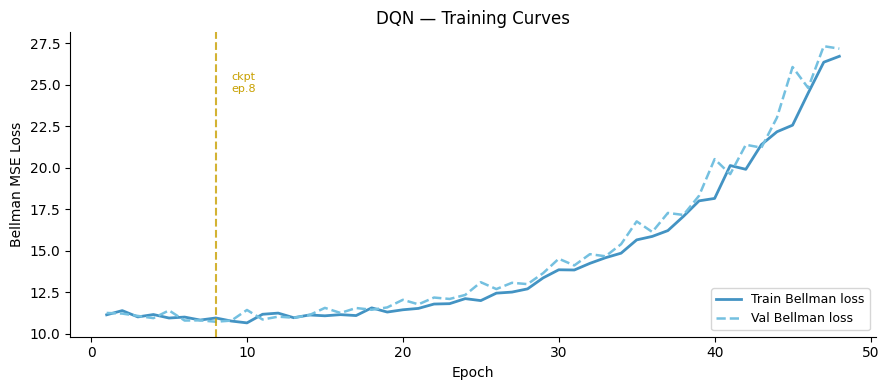

In [17]:
# ── Training curves — DQN ─────────────────────────────────────────────
df_dqn = pd.DataFrame(dqn_history)
best_ep = int(df_dqn.loc[df_dqn['val_loss'].idxmin(), 'epoch'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_dqn['epoch'], df_dqn['train_loss'], color='#4393C3', lw=2, label='Train Bellman loss')
ax.plot(df_dqn['epoch'], df_dqn['val_loss'],   color='#74C0E0', lw=1.8, ls='--', label='Val Bellman loss')
ax.axvline(best_ep, color='#C8A000', lw=1.5, ls='--', alpha=0.8)
ax.text(best_ep + 1, df_dqn['train_loss'].max() * 0.92,
        f'ckpt\nep.{best_ep}', fontsize=8, color='#C8A000')
ax.set_xlabel('Epoch')
ax.set_ylabel('Bellman MSE Loss')
ax.set_title('DQN — Training Curves')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_dqn_training.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
dqn_results = evaluate_policy(dqn_policy, method_name='DQN')


 Evaluating: DQN
  [1/5] Computing CVR (policy rollout)...
  [2/5] Computing BC accuracy...
  [3/5] Applying Safe Actions filter...
  [4/5] Computing Survival Rate...
  [5/5] Running FQE...
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 35  (val Bellman loss = 9.4955)

  Results — DQN
  CVR total   : 3.69%  (C1=14.65% C2=0.00% C3=0.00% C4=0.12%)
  Safe CVR    : 0.11%  (interventions=16.7%)
  BC  top1=1.6%  top3=4.6%
  SR  66.38%  (ΔSR=+6.36 pp)
  FQE V=6.5276  ΔV=+6.5276
  Saved -> c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\experiments\baselines_dqn.json


---
## 7. Baseline 3 — IQL (Implicit Q-Learning)

IQL is the **state-of-the-art unconstrained offline RL** algorithm used as the backbone of CPQ-IQL.
Without the Lagrangian constraint penalties, IQL represents the pure offline RL solution.
It is the most important baseline: any CVR improvement of CPQ-IQL over IQL isolates the
contribution of the constraint penalty mechanism alone.

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `tau` | 0.8 | IQL expectile — matches CPQ-IQL |
| `beta` | 3.0 | Policy temperature (no annealing needed without constraint penalties) |
| `lr_q`, `lr_v` | 1e-4 | Matches CPQ-IQL |
| `soft_update_rho` | 0.005 | Matches CPQ-IQL |

In [19]:
CKPT_IQL_BEST = os.path.join(MODEL_IQL, 'best_iql.pt')
HIST_IQL_CSV  = os.path.join(EXP_DIR, 'iql_training_history.csv')

iql_trainer = IQLTrainer(
    state_dim       = STATE_DIM,
    n_actions       = N_ACTIONS,
    hidden          = (256, 256),
    gamma           = GAMMA,
    tau             = 0.8,
    beta            = 3.0,
    lr_q            = 1e-4,
    lr_v            = 1e-4,
    soft_update_rho = 0.005,
    grad_clip       = 1.0,
    device          = DEVICE,
    seed            = SEED,
)

n_q = sum(p.numel() for p in iql_trainer.Q.parameters())
n_v = sum(p.numel() for p in iql_trainer.V.parameters())
print(f'IQL — Q: {n_q:,}  V: {n_v:,}  Total: {n_q+n_v:,} parameters')

if os.path.isfile(CKPT_IQL_BEST) and os.path.isfile(HIST_IQL_CSV):
    print('Checkpoint detected — loading IQL weights.')
    iql_trainer.load(CKPT_IQL_BEST)
    iql_history = pd.read_csv(HIST_IQL_CSV).to_dict('records')
    print(f'Resumed: {len(iql_history)} epochs from history.')
else:
    print('Training IQL from scratch (up to 300 epochs, early stopping patience=40)...')
    t0 = time.time()
    iql_history = iql_trainer.fit(
        dataloader     = train_loader,
        val_dataloader = val_loader,
        n_epochs       = 300,
        save_dir       = MODEL_IQL,
        log_every      = 10,
        patience       = 40,
        min_delta      = 1e-3,
    )
    print(f'Training complete in {(time.time()-t0)/60:.1f} min.')
    pd.DataFrame(iql_history).to_csv(HIST_IQL_CSV, index=False)

iql_policy = iql_trainer.get_policy()
print(iql_policy)

IQL — Q: 86,809  V: 80,641  Total: 167,450 parameters
Training IQL from scratch (up to 300 epochs, early stopping patience=40)...
  [IQL] epoch   10 | Q(train=10.9039, val=10.8428) | V(train=0.0324, val=0.0303)
  [IQL] epoch   20 | Q(train=10.1960, val=10.4046) | V(train=0.0749, val=0.0966)
  [IQL] epoch   30 | Q(train=10.1634, val=10.2791) | V(train=0.1116, val=0.1237)
  [IQL] epoch   40 | Q(train=9.9044, val=10.1665) | V(train=0.1300, val=0.1438)
  [IQL] epoch   50 | Q(train=9.8679, val=10.0889) | V(train=0.1427, val=0.1700)
  [IQL] epoch   60 | Q(train=9.8715, val=10.0385) | V(train=0.1470, val=0.1739)
  [IQL] epoch   70 | Q(train=9.6367, val=9.9986) | V(train=0.1529, val=0.1843)
  [IQL] epoch   80 | Q(train=9.9296, val=9.9941) | V(train=0.1571, val=0.1887)
  [IQL] epoch   90 | Q(train=9.6724, val=10.0212) | V(train=0.1615, val=0.1944)
  [IQL] epoch  100 | Q(train=9.7549, val=10.0343) | V(train=0.1676, val=0.1993)
  [IQL] epoch  110 | Q(train=9.8344, val=10.0877) | V(train=0.1736, v

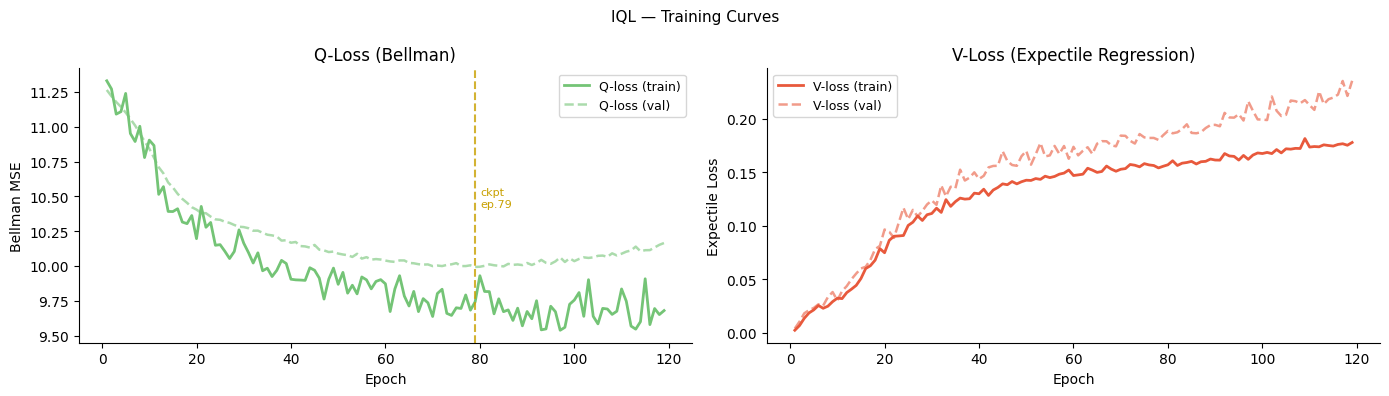

In [20]:
# ── Training curves — IQL ─────────────────────────────────────────────
df_iql   = pd.DataFrame(iql_history)
best_iql = int(df_iql.loc[df_iql['val_q'].idxmin(), 'epoch'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('IQL — Training Curves', fontsize=11)

ax = axes[0]
ax.plot(df_iql['epoch'], df_iql['train_q'], color='#74C476', lw=2,   label='Q-loss (train)')
ax.plot(df_iql['epoch'], df_iql['val_q'],   color='#74C476', lw=1.8, ls='--', alpha=0.6, label='Q-loss (val)')
ax.axvline(best_iql, color='#C8A000', lw=1.5, ls='--', alpha=0.8)
ax.text(best_iql + 1, df_iql['train_q'].max() * 0.92,
        f'ckpt\nep.{best_iql}', fontsize=8, color='#C8A000')
ax.set_xlabel('Epoch'); ax.set_ylabel('Bellman MSE')
ax.set_title('Q-Loss (Bellman)');
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
ax2.plot(df_iql['epoch'], df_iql['train_v'], color='#E8593C', lw=2,   label='V-loss (train)')
ax2.plot(df_iql['epoch'], df_iql['val_v'],   color='#E8593C', lw=1.8, ls='--', alpha=0.6, label='V-loss (val)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Expectile Loss')
ax2.set_title('V-Loss (Expectile Regression)');
ax2.legend(fontsize=9); ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '02_iql_training.png'), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
iql_results = evaluate_policy(iql_policy, method_name='IQL')


 Evaluating: IQL
  [1/5] Computing CVR (policy rollout)...
  [2/5] Computing BC accuracy...
  [3/5] Applying Safe Actions filter...
  [4/5] Computing Survival Rate...
  [5/5] Running FQE...
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 28  (val Bellman loss = 9.9945)

  Results — IQL
  CVR total   : 7.33%  (C1=3.14% C2=0.97% C3=23.58% C4=1.63%)
  Safe CVR    : 1.00%  (interventions=22.0%)
  BC  top1=3.8%  top3=10.9%
  SR  63.51%  (ΔSR=+3.50 pp)
  FQE V=8.3006  ΔV=+8.3006
  Saved -> c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\experiments\baselines_iql.json


---
## 8. Baseline 4 — CQL (Conservative Q-Learning)

CQL (Kumar et al., NeurIPS 2020) adds a **conservative regularisation** that penalises
Q-values of actions not represented in the dataset:

$$L_{\text{CQL}}(\theta) = \alpha\;\bigl(\mathbb{E}_{s\sim D}[\text{logsumexp}_a\,Q(s,a)] - \mathbb{E}_{(s,a)\sim D}[Q(s,a)]\bigr) + \frac{1}{2}\,\text{Bellman loss}$$

This is the method used by **Tu et al. (2025)** for safe sepsis treatment.  Here CQL is trained
**without** the Apache II intermediate rewards.

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `alpha_cql` | 0.05 | Best value found by Tu et al. (2025) grid search |
| `lr` | 1e-5 | Lower rate needed for stable CQL convergence |
| `target_update_freq` | 100 | Prevents oscillation |
| `hidden` | (256, 256) | Matches CPQ-IQL architecture |

In [22]:
CKPT_CQL_BEST = os.path.join(MODEL_CQL, 'best_cql.pt')
HIST_CQL_CSV  = os.path.join(EXP_DIR, 'cql_training_history.csv')

cql_trainer = CQLTrainer(
    state_dim          = STATE_DIM,
    n_actions          = N_ACTIONS,
    hidden             = (256, 256),
    gamma              = GAMMA,
    alpha_cql          = 0.05,
    lr                 = 1e-5,
    target_update_freq = 100,
    grad_clip          = 1.0,
    device             = DEVICE,
    seed               = SEED,
)

n_cql = sum(p.numel() for p in cql_trainer.Q.parameters())
print(f'CQL — Q-network (twin): {n_cql:,} parameters')

if os.path.isfile(CKPT_CQL_BEST) and os.path.isfile(HIST_CQL_CSV):
    print('Checkpoint detected — loading CQL weights.')
    cql_trainer.load(CKPT_CQL_BEST)
    cql_history = pd.read_csv(HIST_CQL_CSV).to_dict('records')
    print(f'Resumed: {len(cql_history)} epochs from history.')
else:
    print('Training CQL from scratch (up to 300 epochs, early stopping patience=40)...')
    t0 = time.time()
    cql_history = cql_trainer.fit(
        dataloader     = train_loader,
        val_dataloader = val_loader,
        n_epochs       = 300,
        save_dir       = MODEL_CQL,
        log_every      = 10,
        patience       = 40,
        min_delta      = 1e-3,
    )
    print(f'Training complete in {(time.time()-t0)/60:.1f} min.')
    pd.DataFrame(cql_history).to_csv(HIST_CQL_CSV, index=False)

cql_policy = cql_trainer.get_policy()
print(cql_policy)

CQL — Q-network (twin): 173,618 parameters
Training CQL from scratch (up to 300 epochs, early stopping patience=40)...
  [CQL] epoch   10 | total=11.5885 | bellman=11.4276 | cql_pen=3.2165 | val=11.2810
  [CQL] epoch   20 | total=11.2330 | bellman=11.0719 | cql_pen=3.2208 | val=11.2287
  [CQL] epoch   30 | total=11.2981 | bellman=11.1359 | cql_pen=3.2435 | val=11.0831
  [CQL] epoch   40 | total=11.1332 | bellman=10.9696 | cql_pen=3.2734 | val=11.0101
  [CQL] epoch   50 | total=11.3141 | bellman=11.1486 | cql_pen=3.3102 | val=11.4264
  [CQL] epoch   60 | total=12.0841 | bellman=11.9164 | cql_pen=3.3531 | val=12.2795
  [CQL] epoch   70 | total=13.1988 | bellman=13.0291 | cql_pen=3.3952 | val=13.6193
  [CQL] Early stopping at epoch 78  (val_loss=14.7416)
Training complete in 2.4 min.
CQLPolicy(greedy on min-Q)


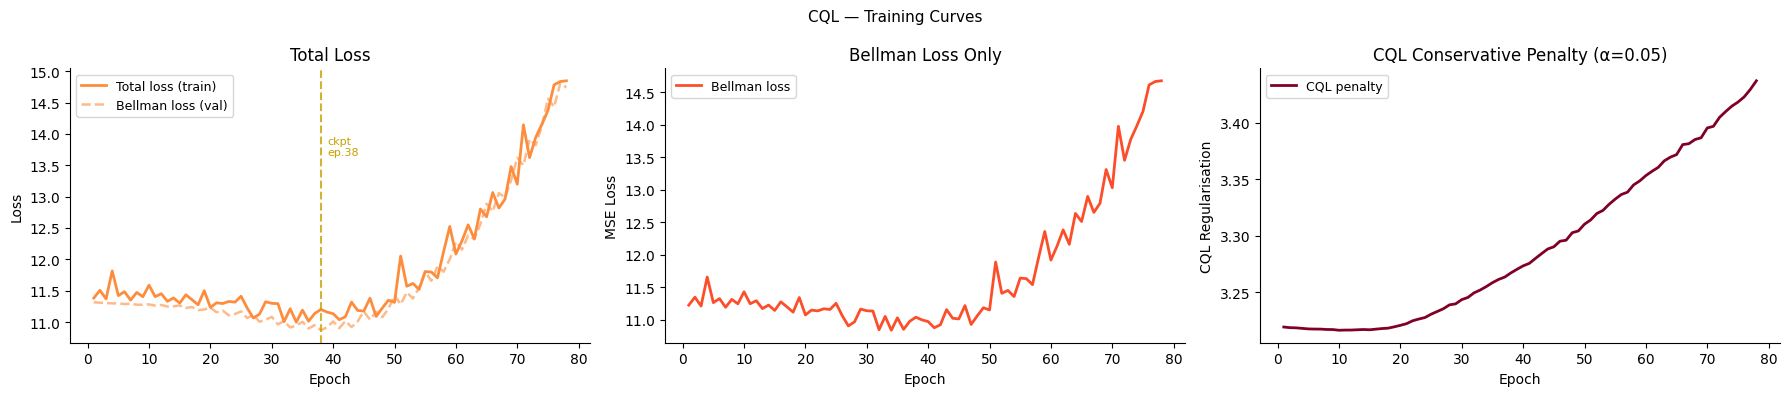

In [23]:
# ── Training curves — CQL (three panels) ─────────────────────────────
df_cql   = pd.DataFrame(cql_history)
best_cql = int(df_cql.loc[df_cql['val_bellman_loss'].idxmin(), 'epoch'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('CQL — Training Curves', fontsize=11)

C_TOTAL   = '#FD8D3C'
C_BELLMAN = '#FC4E2A'
C_CQL_PEN = '#800026'

ax = axes[0]
ax.plot(df_cql['epoch'], df_cql['total_loss'],   color=C_TOTAL,   lw=2,   label='Total loss (train)')
ax.plot(df_cql['epoch'], df_cql['val_bellman_loss'], color=C_TOTAL, lw=1.8, ls='--', alpha=0.6, label='Bellman loss (val)')
ax.axvline(best_cql, color='#C8A000', lw=1.5, ls='--', alpha=0.8)
ax.text(best_cql + 1, df_cql['total_loss'].max() * 0.92,
        f'ckpt\nep.{best_cql}', fontsize=8, color='#C8A000')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Total Loss'); ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

ax2 = axes[1]
ax2.plot(df_cql['epoch'], df_cql['bellman_loss'], color=C_BELLMAN, lw=2, label='Bellman loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')
ax2.set_title('Bellman Loss Only'); ax2.legend(fontsize=9)
ax2.spines[['top','right']].set_visible(False)

ax3 = axes[2]
ax3.plot(df_cql['epoch'], df_cql['cql_loss'], color=C_CQL_PEN, lw=2, label='CQL penalty')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('CQL Regularisation')
ax3.set_title(f'CQL Conservative Penalty (α={cql_trainer.alpha_cql})')
ax3.legend(fontsize=9)
ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '03_cql_training.png'), dpi=150, bbox_inches='tight')
plt.show()

In [24]:
cql_results = evaluate_policy(cql_policy, method_name='CQL')


 Evaluating: CQL
  [1/5] Computing CVR (policy rollout)...
  [2/5] Computing BC accuracy...
  [3/5] Applying Safe Actions filter...
  [4/5] Computing Survival Rate...
  [5/5] Running FQE...
  FQE.fit: preparing training data...
  FQE.fit: training evaluation Q-network...
  FQE.fit: converged at epoch 30  (val Bellman loss = 9.8223)

  Results — CQL
  CVR total   : 4.18%  (C1=5.65% C2=0.17% C3=8.55% C4=2.34%)
  Safe CVR    : 0.30%  (interventions=15.6%)
  BC  top1=4.2%  top3=7.9%
  SR  67.33%  (ΔSR=+7.32 pp)
  FQE V=6.1992  ΔV=+6.1992
  Saved -> c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\experiments\baselines_cql.json


---
## 9. Cross-Method Comparison Figures

Four panels summarise all four baselines across key dimensions.  


In [25]:
# ── Load all results (supports resuming from saved artefacts) ─────────
_METHODS = ['Random', 'DQN', 'IQL', 'CQL']
_all = {}
for m in _METHODS:
    try:
        _all[m] = load_baseline_results(m.lower(), EXP_DIR)
    except FileNotFoundError as e:
        print(f'WARNING: {e}')

print('Available results:', list(_all.keys()))

Available results: ['Random', 'DQN', 'IQL', 'CQL']


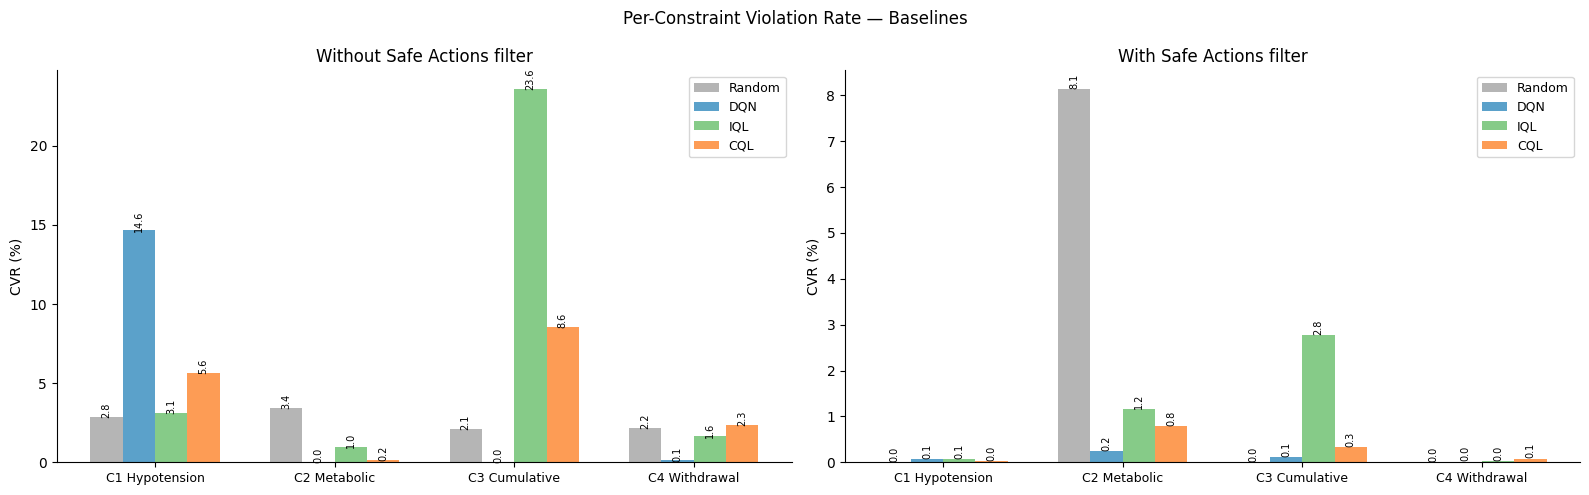

In [26]:
# ──────────────────────────────────────────────────────────────────────
# Figure 1: Per-constraint CVR (with and without Safe Actions)
# ──────────────────────────────────────────────────────────────────────
methods  = [m for m in _METHODS if m in _all]
n_m      = len(methods)
x        = np.arange(len(CONSTRAINT_NAMES))
bar_w    = 0.18

cvr_keys  = ['C1_hypotension', 'C2_metabolic', 'C3_cumulative', 'C4_withdrawal']
safe_keys = ['safe_C1_hypotension', 'safe_C2_metabolic', 'safe_C3_cumulative', 'safe_C4_withdrawal']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Per-Constraint Violation Rate — Baselines', fontsize=12)

for ax_idx, (keys_key, ax, title) in enumerate(zip(
    ['cvr_rollout', 'safe_actions'],
    axes,
    ['Without Safe Actions filter', 'With Safe Actions filter'],
)):
    keys = cvr_keys if ax_idx == 0 else safe_keys
    for i, m in enumerate(methods):
        vals = [_all[m][keys_key].get(k, float('nan')) * 100 for k in keys]
        offset = (i - n_m / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w, label=m,
                      color=METHOD_COLORS[m], alpha=0.87)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        v + 0.05, f'{v:.1f}', ha='center',
                        fontsize=7, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(CONSTRAINT_NAMES, fontsize=9)
    ax.set_ylabel('CVR (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_cvr_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

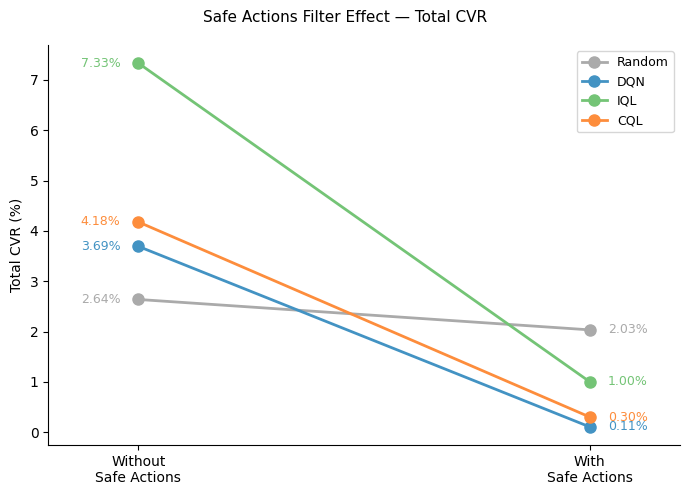

In [27]:
# ──────────────────────────────────────────────────────────────────────
# Figure 2: Safe Actions slope graph — total CVR before vs after filter
# ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Safe Actions Filter Effect — Total CVR', fontsize=11)

for m in methods:
    cvr_before = _all[m]['cvr_rollout'].get('total_cvr', float('nan')) * 100
    cvr_after  = _all[m]['safe_actions'].get('safe_total_cvr', float('nan')) * 100
    col        = METHOD_COLORS[m]
    ax.plot([0, 1], [cvr_before, cvr_after], 'o-', color=col, lw=2, ms=8, label=m)
    ax.text(-0.04, cvr_before, f'{cvr_before:.2f}%', ha='right', va='center',
            fontsize=9, color=col)
    ax.text(1.04,  cvr_after,  f'{cvr_after:.2f}%',  ha='left',  va='center',
            fontsize=9, color=col)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Without\nSafe Actions', 'With\nSafe Actions'], fontsize=10)
ax.set_ylabel('Total CVR (%)')
ax.set_xlim(-0.2, 1.2)
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '05_safe_actions_slope.png'), dpi=150, bbox_inches='tight')
plt.show()

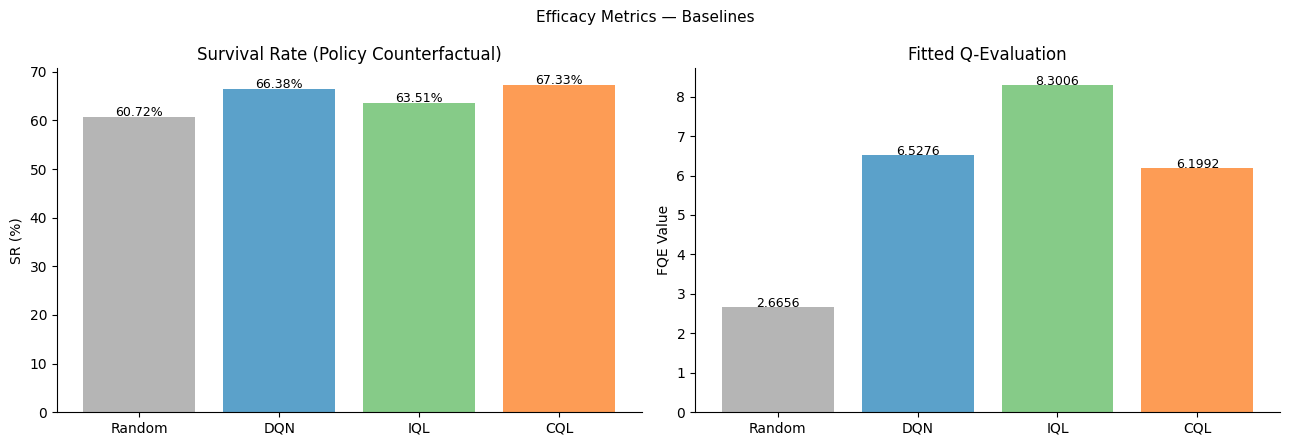

In [28]:
# ──────────────────────────────────────────────────────────────────────
# Figure 3: Survival Rate and FQE
# ──────────────────────────────────────────────────────────────────────
sr_vals  = [_all[m]['survival_rate'].get('sr_policy', float('nan')) * 100 for m in methods]
fqe_vals = [_all[m]['fqe'].get('v_fqe', float('nan'))                     for m in methods]
cols     = [METHOD_COLORS[m] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Efficacy Metrics — Baselines', fontsize=11)

# SR
bars = axes[0].bar(methods, sr_vals, color=cols, alpha=0.87)
for bar, v in zip(bars, sr_vals):
    if not np.isnan(v):
        axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                     f'{v:.2f}%', ha='center', fontsize=9)
axes[0].set_ylabel('SR (%)')
axes[0].set_title('Survival Rate (Policy Counterfactual)')
axes[0].spines[['top', 'right']].set_visible(False)

# FQE
bars2 = axes[1].bar(methods, fqe_vals, color=cols, alpha=0.87)
for bar, v in zip(bars2, fqe_vals):
    if not np.isnan(v):
        axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                     f'{v:.4f}', ha='center', fontsize=9)
axes[1].set_ylabel('FQE Value')
axes[1].set_title('Fitted Q-Evaluation')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '06_sr_fqe.png'), dpi=150, bbox_inches='tight')
plt.show()

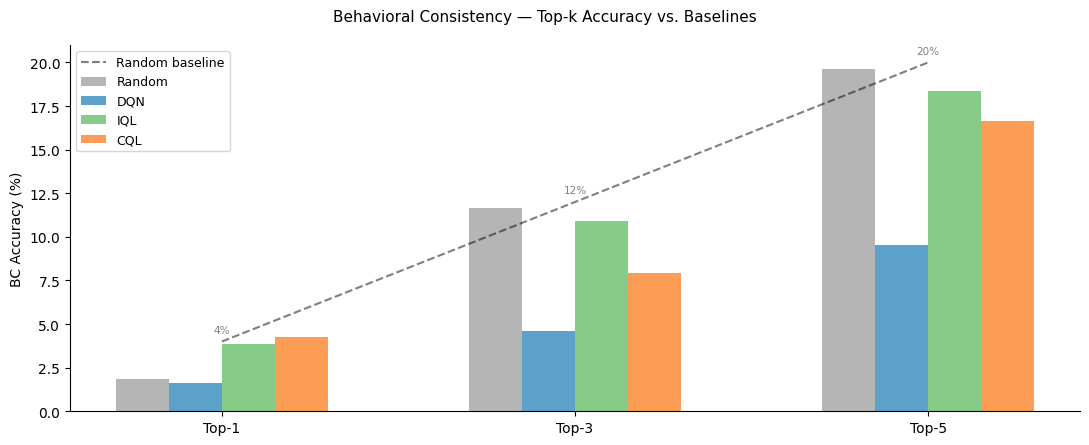

In [29]:
# ──────────────────────────────────────────────────────────────────────
# Figure 4: Behavioral Consistency (BC top-k)
# ──────────────────────────────────────────────────────────────────────
k_vals  = [1, 3, 5]
bc_rand = [k / N_ACTIONS * 100 for k in k_vals]
x_bc    = np.arange(len(k_vals))
bar_w_bc = 0.15

fig, ax = plt.subplots(figsize=(11, 4.5))
fig.suptitle('Behavioral Consistency — Top-k Accuracy vs. Baselines', fontsize=11)

for i, m in enumerate(methods):
    bc_obs = [_all[m]['bc_accuracy'].get(f'top{k}', float('nan')) * 100 for k in k_vals]
    offset = (i - n_m / 2 + 0.5) * bar_w_bc
    bars = ax.bar(x_bc + offset, bc_obs, bar_w_bc, label=m,
                  color=METHOD_COLORS[m], alpha=0.87)

ax.plot(x_bc, bc_rand, 'k--', lw=1.5, label='Random baseline', alpha=0.5)
for xi, r in enumerate(bc_rand):
    ax.text(xi, r + 0.5, f'{r:.0f}%', ha='center', fontsize=7.5, color='gray')

ax.set_xticks(x_bc)
ax.set_xticklabels([f'Top-{k}' for k in k_vals])
ax.set_ylabel('BC Accuracy (%)')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '07_bc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary Table

In [30]:
SUMMARY_CSV = os.path.join(EXP_DIR, 'baselines_summary.csv')

df_summary = build_summary_csv(
    exp_dir  = EXP_DIR,
    methods  = [m.lower() for m in _METHODS],
    out_path = SUMMARY_CSV,
)

print('Baselines summary table')
print('=' * 90)
display_cols = [
    'method',
    'cvr_total', 'safe_cvr_total', 'intervention_rate',
    'sr_policy', 'delta_sr', 'v_fqe',
    'bc_top1', 'bc_top3',
]
print(df_summary[display_cols].to_string(index=False, float_format='{:.2f}'.format))
print(f'\nFull table saved → {SUMMARY_CSV}')

Baselines summary table
method  cvr_total  safe_cvr_total  intervention_rate  sr_policy  delta_sr  v_fqe  bc_top1  bc_top3
random       2.64            2.03              16.69      60.72      0.70   2.67     1.88    11.68
   dqn       3.69            0.11              16.69      66.38      6.36   6.53     1.62     4.62
   iql       7.33            1.00              22.00      63.51      3.50   8.30     3.83    10.92
   cql       4.18            0.30              15.62      67.33      7.32   6.20     4.25     7.94

Full table saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\experiments\baselines_summary.csv


---
## 11. Artefact Export



In [31]:
def _print_tree(root, indent=''):
    for entry in sorted(os.listdir(root)):
        fp = os.path.join(root, entry)
        if os.path.isfile(fp):
            rel = os.path.relpath(fp, PROJECT_ROOT)
            print(f'  {rel:<60} {os.path.getsize(fp)/1e3:>8.1f} KB')
        elif os.path.isdir(fp):
            _print_tree(fp)

print('=' * 75)
print('Exported artefacts — Baselines notebook')
print('=' * 75)

for dirpath in [MODEL_DQN, MODEL_IQL, MODEL_CQL, FIG_DIR]:
    if os.path.isdir(dirpath):
        _print_tree(dirpath)

# Experiments (JSON + CSV artefacts for this notebook)
if os.path.isdir(EXP_DIR):
    for fn in sorted(os.listdir(EXP_DIR)):
        if 'baseline' in fn or 'dqn' in fn or 'iql' in fn or 'cql' in fn:
            fp  = os.path.join(EXP_DIR, fn)
            rel = os.path.relpath(fp, PROJECT_ROOT)
            print(f'  {rel:<60} {os.path.getsize(fp)/1e3:>8.1f} KB')

Exported artefacts — Baselines notebook
  models\dqn\best_dqn.pt                                          350.3 KB
  models\dqn\final_dqn.pt                                         350.3 KB
  models\iql\best_iql.pt                                          674.6 KB
  models\iql\final_iql.pt                                         674.6 KB
  models\cql\best_cql.pt                                          699.2 KB
  models\cql\final_cql.pt                                         699.2 KB
  figures\baselines\01_clinician_baseline.png                      94.2 KB
  figures\baselines\01_dqn_training.png                            62.0 KB
  figures\baselines\02_iql_training.png                           129.1 KB
  figures\baselines\03_cql_training.png                           132.3 KB
  figures\baselines\04_cvr_comparison.png                          60.2 KB
  figures\baselines\05_safe_actions_slope.png                      68.2 KB
  figures\baselines\06_sr_fqe.png                           